ВАРИАНТ 2: Классификация видов ДТП
(упрощенная)

Версии библиотек:
Python version: 3.10.14 
pandas: 2.1.4
numpy: 1.26.4
scikit-learn: 1.4.2
matplotlib: 3.7.5
seaborn: 0.13.2
xgboost: 3.0.2
lightgbm: 4.6.0
imbalanced-learn: 0.12.3
shap: 0.49.1
joblib: 1.3.2
pycaret: 3.3.2

EDA

In [5]:
#Загрузка и первичная обработка данных
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# отображение
pd.set_option('display.max_columns', None)

# загрузка данных
df = pd.read_excel(r"C:\Users\afoni\Downloads\DATA.xlsx")

# размер датасета
print("Размер датасета:", df.shape)

# первые строки
display(df.head())

# информация о данных
df.info()

#Фильтрация зимних месяцев
# преобразуем дату
df['Дата'] = pd.to_datetime(df['Дата'], dayfirst=True)

# зимние месяцы
winter_months = [12, 1, 2]

# фильтрация
df = df[df['Дата'].dt.month.isin(winter_months)]

print("Размер после фильтрации:", df.shape)

Размер датасета: (7992, 24)


,Дата,Время,Вид ДТП,transp_amount,loss_amount,Округ,cut_code,cut_pr_code,traffic_lane_amount,dtp_traffic_lane,traffic_area_width,wayside_width,sidewalk_width,center_mall_width,cmall_type_code,srf_code,tr_area_state_code,light_type_code,rate_code,road_constructions_here,road_constructions_there,meteo_clouds,road_drawbacks,motion_influences
0,2020-01-04,04:35:00,Наезд на пешехода,1,0,Московская область,Прямая в плане,Горизонтальный,9,8,153,15,15,5,Разделительная полоса отсутствует,Асфальтобетонное,Мокрое,"В темное время суток, освещение включено",Движение частично перекрыто,"['Регулируемый пешеходный переход', 'Регулируе...",['Отсутствие в непосредственной близости объек...,['Снегопад'],['Отсутствие перечисленных недостатков транспо...,['Факторы отсутствуют']
1,2020-01-04,09:20:00,Столкновение,4,0,САО,Прямая в плане,Вершина подъема (начало спуска),11,8,239,5,5,10,Разделительная полоса с барьером в виде металл...,Асфальтобетонное,Гололедица,"В темное время суток, освещение не включено",Режим движения не изменялся,"['Мост, эстакада, путепровод']",['Отсутствие в непосредственной близости объек...,['Пасмурно'],['Недостатки зимнего содержания. (Несвоевремен...,['Факторы отсутствуют']
2,2020-01-04,11:00:00,Наезд на препятствие,1,0,ЮЗАО,Прямая в плане,Горизонтальный,8,6,117,5,35,20,Разделительная полоса с грунтовым покрытием,Асфальтобетонное,Мокрое,Светлое время суток,Режим движения не изменялся,['Регулируемый перекресток'],"['Подземный пешеходный переход', 'Многоквартир...",['Пасмурно'],['Отсутствие перечисленных недостатков транспо...,['Факторы отсутствуют']
3,2020-01-04,05:05:00,Наезд на препятствие,3,0,ЮАО,Прямая в плане,Горизонтальный,9,9,137,5,25,20,Разделительная полоса с барьером в виде металл...,Асфальтобетонное,Мокрое,"В темное время суток, освещение включено",Движение частично перекрыто,['Перегон (нет объектов на месте ДТП)'],"['Остановка общественного транспорта', 'Подзем...",['Дождь'],['Отсутствие перечисленных недостатков транспо...,"['Участок, контролируемый камерами автоматичес..."
4,2020-01-06,21:11:00,Наезд на препятствие,1,1,ЮВАО,Прямая в плане,Горизонтальный,9,9,165,5,35,5,Разделительная полоса отсутствует,Асфальтобетонное,Обработанное противогололедными материалами,"В темное время суток, освещение включено",Движение частично перекрыто,['Перегон (нет объектов на месте ДТП)'],"['Остановка общественного транспорта', 'Многок...",['Пасмурно'],['Отсутствие перечисленных недостатков транспо...,['Факторы отсутствуют']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7992 entries, 0 to 7991
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Дата                      7992 non-null   datetime64[ns]
 1   Время                     7992 non-null   object        
 2   Вид ДТП                   7992 non-null   object        
 3   transp_amount             7992 non-null   int64         
 4   loss_amount               7992 non-null   int64         
 5   Округ                     7992 non-null   object        
 6   cut_code                  7991 non-null   object        
 7   cut_pr_code               7991 non-null   object        
 8   traffic_lane_amount       7992 non-null   int64         
 9   dtp_traffic_lane          7992 non-null   int64         
 10  traffic_area_width        7992 non-null   int64         
 11  wayside_width             7992 non-null   int64         
 12  sidewalk_width      

Вывод:
После фильтрации по зимним месяцам осталось 2266 наблюдений.

In [7]:
#Создание целевой переменной
# функция агрегации видов ДТП
def group_dtp(x):

    x = str(x).lower()

    if 'наезд' in x:
        return 'Наезд'

    elif 'столкнов' in x:
        return 'Столкновение'

    else:
        return 'Прочее'

# новая target переменная
df['target'] = df['Вид ДТП'].apply(group_dtp)

# распределение классов
print(df['target'].value_counts())


target
Наезд           1156
Столкновение     996
Прочее           114
Name: count, dtype: int64


In [8]:
df['hour'] = df['Время'].apply(lambda t: t.hour)
df['hour'] = df['Время'].apply(lambda t: t.hour)

# День недели (0=понедельник, 6=воскресенье)
df['dayofweek'] = df['Дата'].dt.dayofweek

# Выходной (суббота, воскресенье)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Час пик (8-10 или 18-20)
df['peak_hour'] = ((df['hour'] >= 8) & (df['hour'] <= 10) |
                   (df['hour'] >= 18) & (df['hour'] <= 20)).astype(int)

X = df.drop(['Дата', 'Время', 'Вид ДТП', 'target'], axis=1)
y = df['target']

Учитывая дисбаланс классов, в качестве основной метрики качества выбрана macro F1-score.


In [10]:
#Анализ пропусков
# анализ пропусков
missing = df.isnull().sum()

# оставляем только признаки с пропусками
missing = missing[missing > 0].sort_values(ascending=False)

# проверка
if len(missing) == 0:
    print("Пропуски в данных отсутствуют")
else:
    print(missing)

    plt.figure(figsize=(12,6))

    missing.plot(kind='bar')

    plt.title('Количество пропусков по признакам')
    plt.ylabel('Количество пропусков')

    plt.xticks(rotation=45)

    plt.show()

Пропуски в данных отсутствуют


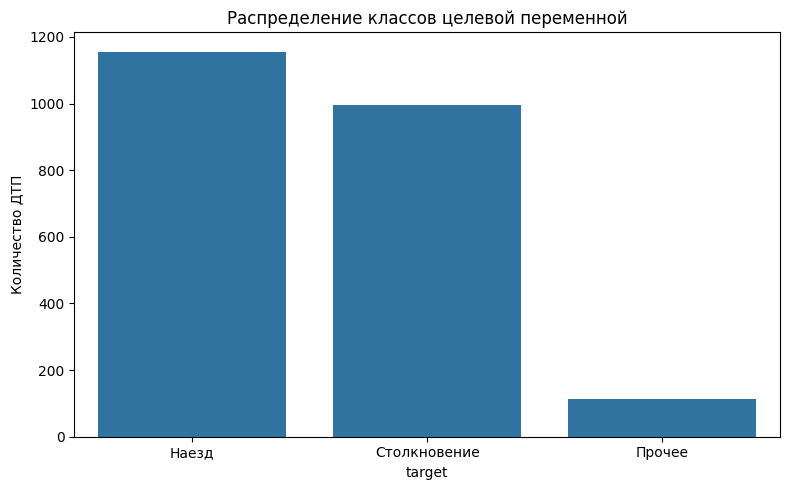

In [11]:
#График 1: Распределение целевой переменной 
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='target', order=df['target'].value_counts().index)
plt.title('Распределение классов целевой переменной')
plt.ylabel('Количество ДТП')
plt.tight_layout()
plt.show()

Вывод: Дисбаланс выраженный: класс 'Прочее' составляет всего 5% от выборки. 
Это означает, что при случайном угадывании точность (accuracy) может быть высокой (~95%), но модель будет плохо предсказывать редкий класс. 
Поэтому основной метрикой качества должна быть macro F1-score или weighted F1-score, а также precision/recall по каждому классу.

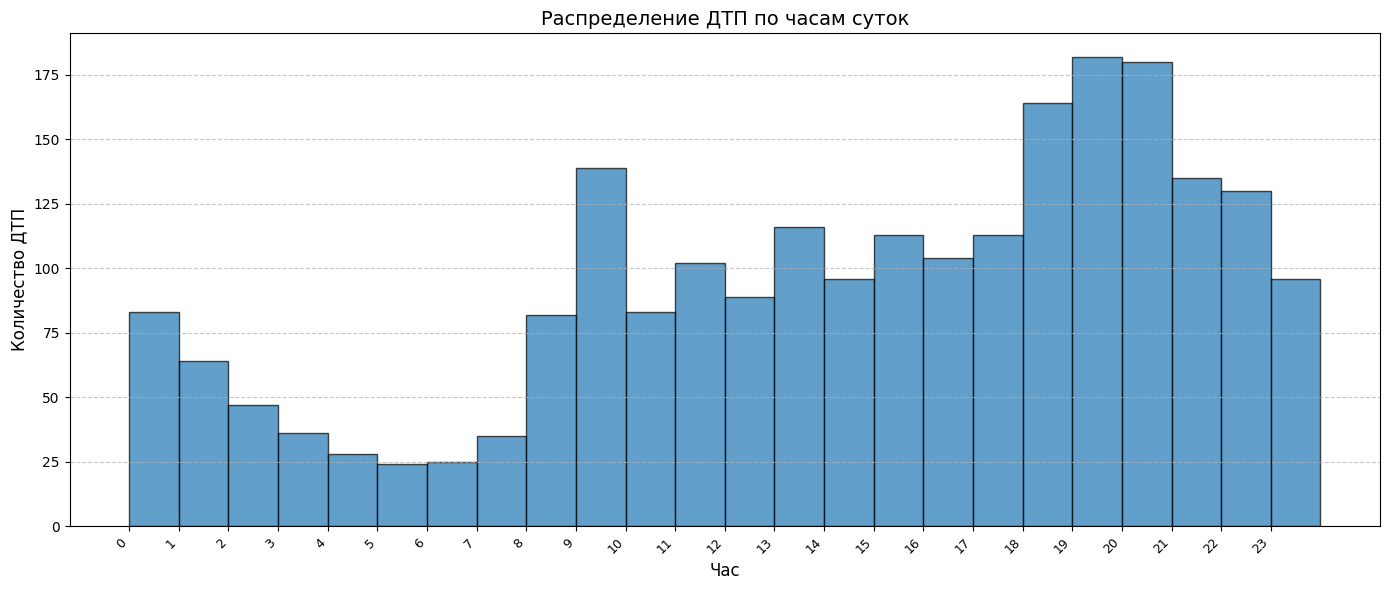

In [13]:
#График 2: Распределение ДТП по часам суток
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# Гистограмма
counts, bins, patches = plt.hist(df['hour'], bins=np.arange(0, 25, 1), edgecolor='black', alpha=0.7)

# Настройка оси X: все часы от 0 до 23
plt.xticks(ticks=np.arange(0, 24, 1), labels=[str(i) for i in range(24)], rotation=45, ha='right', fontsize=9)

plt.title('Распределение ДТП по часам суток', fontsize=14)
plt.xlabel('Час', fontsize=12)
plt.ylabel('Количество ДТП', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
#Вывод: Пик ДТП приходится на вечерние часы, что связано с интенсивностью движения.

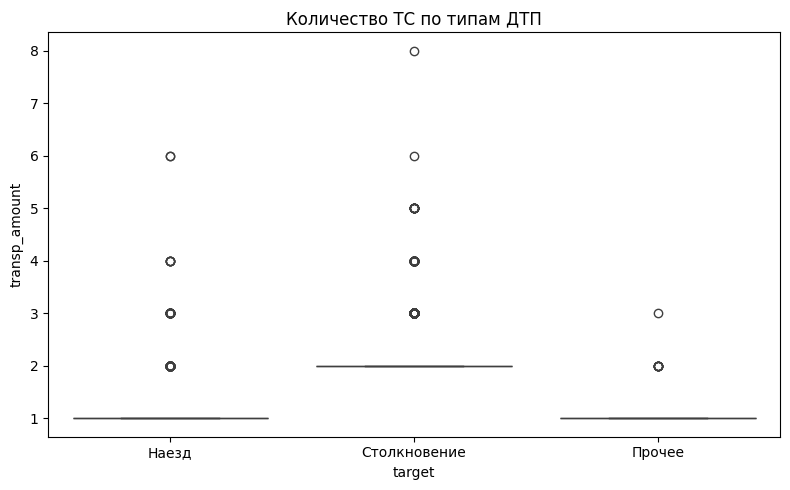

In [14]:
#Количество ТС по типам ДТП
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='target', y='transp_amount')
plt.title('Количество ТС по типам ДТП')
plt.tight_layout()
plt.show()
#Вывод: Для "Столкновения" характерно большее количество ТС, есть выбросы (массовые аварии).

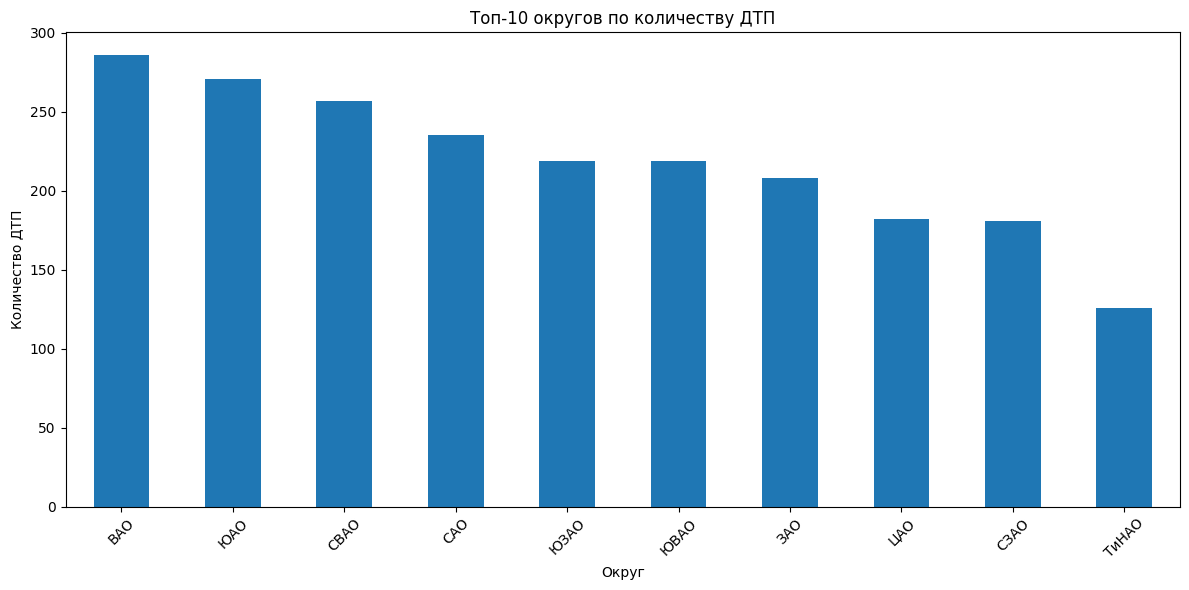

In [15]:
#График 4: Распределение ДТП по округам
plt.figure(figsize=(12,6))
df['Округ'].value_counts().head(10).plot(kind='bar')
plt.title('Топ-10 округов по количеству ДТП')
plt.ylabel('Количество ДТП')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#Вывод: Больше всего ДТП в крупных округах (ВАО, ЮАО, СВАО, САО). 
#Это ожидаемо, так как там выше плотность населения и трафика.

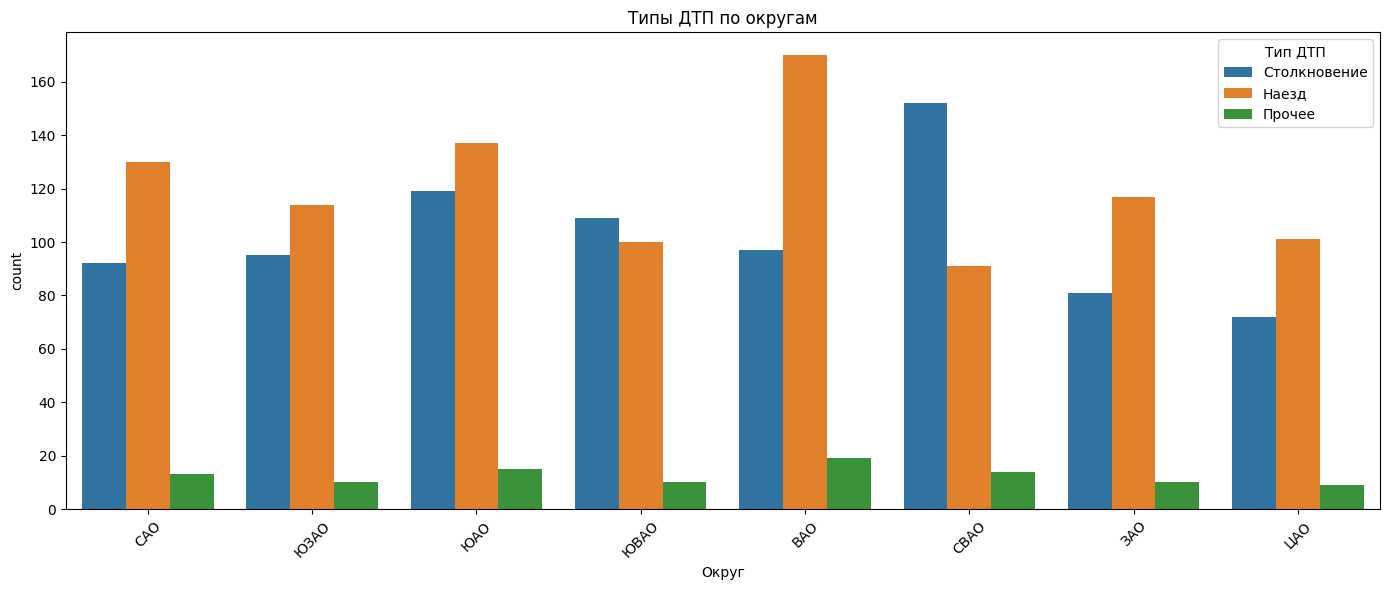

In [16]:
#График 5: Типы ДТП по округам
plt.figure(figsize=(14,6))
top_districts = df['Округ'].value_counts().head(8).index
df_top = df[df['Округ'].isin(top_districts)]
sns.countplot(data=df_top, x='Округ', hue='target')
plt.title('Типы ДТП по округам')
plt.xticks(rotation=45)
plt.legend(title='Тип ДТП')
plt.tight_layout()
plt.show()
#Вывод: В округах ВАО и СВАО большой разрыв между столкновениями и наездами, 
#в округах САО, ЗАО, ЦАО средний разрыв и наезды преобладают над столкновениями.

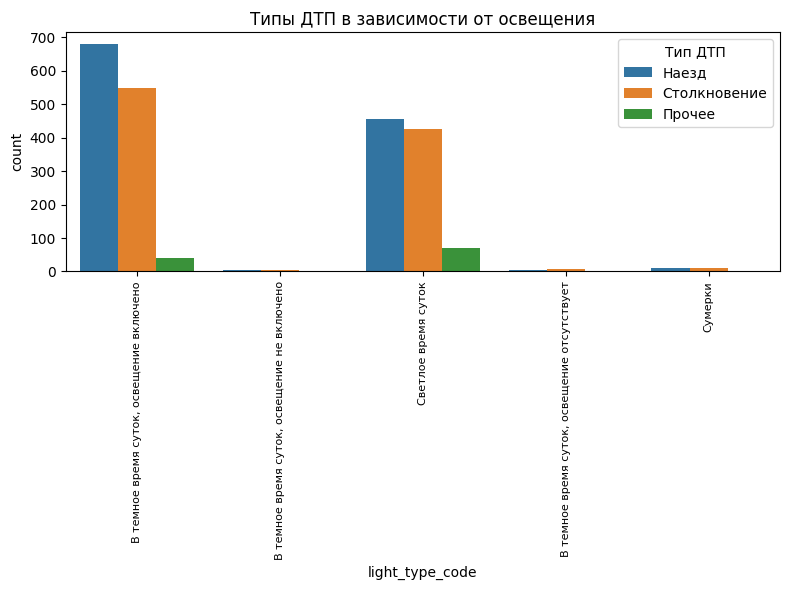

In [17]:
#График 6: Типы ДТП по освещению 
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='light_type_code', hue='target')
plt.title('Типы ДТП в зависимости от освещения', fontsize=12)
plt.xticks(rotation=90, fontsize=8, ha='center')  # вертикальные подписи
plt.legend(title='Тип ДТП')
plt.tight_layout()
plt.show()
#Вывод: Большое количество ДТП происходит в темное время суток с включенным освещением и 
#в светлое время суток, что может говорить о том,что большая часть ДТП (преобладают наезды) 
#происходит в населенных пунктах с большим трафиком.

In [18]:
print(df['light_type_code'].value_counts())

light_type_code
В темное время суток, освещение включено       1271
Светлое время суток                             954
Сумерки                                          20
В темное время суток, освещение отсутствует      13
В темное время суток, освещение не включено       8
Name: count, dtype: int64


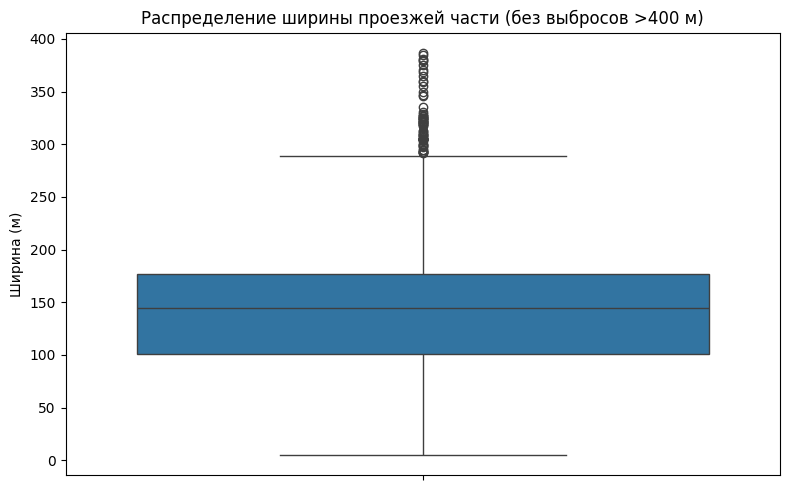

In [19]:
#График 7:Распределение ДТП в зависимости от ширины проезжей части
import matplotlib.pyplot as plt
import seaborn as sns

# Удаляем заведомо ошибочные значения (> 400 м)
df_clean = df[df['traffic_area_width'] <= 400]

plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, y='traffic_area_width')
plt.title('Распределение ширины проезжей части (без выбросов >400 м)')
plt.ylabel('Ширина (м)')
plt.tight_layout()
plt.show()
#Вывод: большая часть ДТП приходится на магистрали (широкие дороги 100-180 м), 
#также присутствует большое количество выбросов.

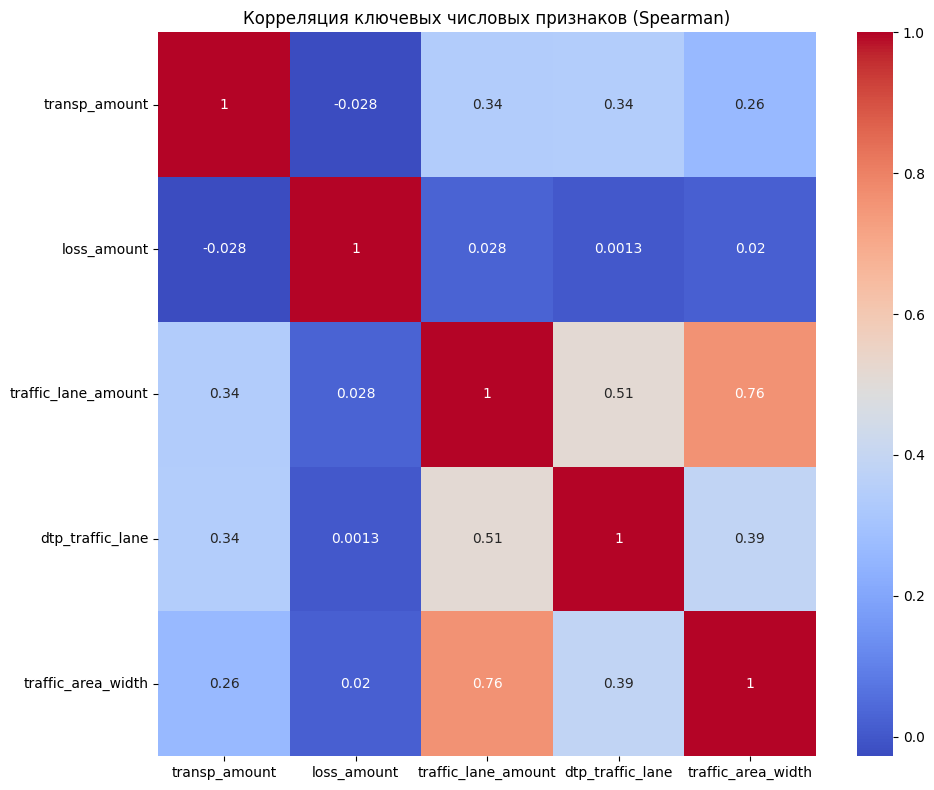

In [20]:
#График 8: Матрица корреляции
numeric_cols = ['transp_amount', 'loss_amount', 'traffic_lane_amount', 
                'dtp_traffic_lane', 'traffic_area_width']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True, cmap='coolwarm')
plt.title('Корреляция ключевых числовых признаков (Spearman)')
plt.tight_layout()
plt.show()
#Вывод: Мультиколлинеарность присутствует: traffic_lane_amount (количество полос) и 
#traffic_area_width (ширина проезжей части) сильно коррелируют (0.76). 
#Это логично: чем больше полос, тем шире дорога.

Общие выводы по EDA:

1. Размер выборки: 2266 наблюдений, пропуски отсутствуют.

2. Дисбаланс классов: класс «Прочее» составляет ≈5% выборки, поэтому основная метрика — macro F1-score (accuracy вводит в заблуждение).  
3. Временной пик: наибольшее число ДТП приходится на вечерние часы (14–20), признак `hour` информативен.  
4. Количество ТС: для «Столкновения» характерно больше участников, есть выбросы (массовые аварии).  
5. География: больше всего ДТП в крупных округах (ВАО, ЮАО, СВАО, САО). В ВАО и СВАО большой разрыв (преобладают наезды), в САО, ЗАО, ЦАО — средний разрыв, также наезды преобладают.  
6. Освещение: наезды чаще происходят в тёмное время суток (особенно с включённым освещением), столкновения равномернее.  
7. Дороги: большинство ДТП — на широких магистралях (ширина 100–200 м). Выбросы (>200 м) не удалялись.  
8. Корреляция: `traffic_lane_amount` и `traffic_area_width` сильно коррелируют (0.76), что ожидаемо. Для Random Forest мультиколлинеарность не критична.  
9. Рекомендации: использовать Random Forest с `class_weight='balanced'` или SMOTE, контролировать качество по macro F1-score и MCC.

ПОДГОТОВКА ДАННЫХ

In [23]:
# Создание матрицы признаков X и целевой переменной y
# Целевая переменная (строки: 'Наезд', 'Столкновение', 'Прочее')
y = df['target']

# Признаки: удаляем лишние столбцы
X = df.drop(['Дата', 'Время', 'Вид ДТП', 'target'], axis=1)
print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

Размер X: (2266, 25)
Размер y: (2266,)


РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ

In [25]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.3
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y   # сохраняем пропорции классов
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (1586, 25)
Тестовая выборка: (680, 25)


Выводы по разделению данных:

- Обучающая выборка: 1586 объектов, тестовая: 680 объектов.

- Стратификация применена, пропорции классов сохранены.

Генерирование признаков

In [28]:
# Преобразование признаков-списков в длину (после разделения на train/test)
import ast

def safe_list_len(x):
    if pd.isna(x):
        return 0
    if isinstance(x, list):
        return len(x)
    try:
        lst = ast.literal_eval(x)
        if isinstance(lst, list):
            return len(lst)
    except:
        pass
    return 0

list_cols = ['road_constructions_here', 'road_constructions_there', 
             'road_drawbacks', 'motion_influences']

for col in list_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].apply(safe_list_len)
        X_test[col] = X_test[col].apply(safe_list_len)
        print(f"{col} преобразован в длину списка")

road_constructions_here преобразован в длину списка
road_constructions_there преобразован в длину списка
road_drawbacks преобразован в длину списка
motion_influences преобразован в длину списка


In [29]:
# КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ 
from sklearn.preprocessing import LabelEncoder

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    n_unique = X_train[col].nunique()
    if n_unique <= 10:
        # One-Hot кодирование
        dummies_train = pd.get_dummies(X_train[col], prefix=col, drop_first=True)
        dummies_test = pd.get_dummies(X_test[col], prefix=col, drop_first=True)
        # Выравниваем столбцы (в тесте может не хватать некоторых категорий)
        dummies_test = dummies_test.reindex(columns=dummies_train.columns, fill_value=0)
        X_train = pd.concat([X_train.drop(columns=[col]), dummies_train], axis=1)
        X_test = pd.concat([X_test.drop(columns=[col]), dummies_test], axis=1)
    else:
        # LabelEncoding с обработкой неизвестных категорий
        le = LabelEncoder()
        # Обучаем на тренировочных данных
        le.fit(X_train[col].astype(str))
        # Преобразуем тренировочные
        X_train[col] = le.transform(X_train[col].astype(str))
        # Для тестовых: заменяем неизвестные категории на -1
        # Создаём словарь для быстрого отображения
        mapping = {label: idx for idx, label in enumerate(le.classes_)}
        X_test[col] = X_test[col].astype(str).map(mapping).fillna(-1).astype(int)
        label_encoders[col] = le

In [30]:
print("Строковые колонки в X_train:", X_train.select_dtypes(include=['object']).columns.tolist())
print("Строковые колонки в X_test :", X_test.select_dtypes(include=['object']).columns.tolist())

Строковые колонки в X_train: []
Строковые колонки в X_test : []


Выводы по подготовке данных:

- Все категориальные признаки закодированы (One-Hot для низкокардинальных, LabelEncoder с обработкой новых категорий для высококардинальных).

- Признаки-списки преобразованы в длину.

- Пропуски отсутствуют.

- Дисбаланс классов сохранён, будет учтён при моделировании через class_weight и SMOTE.

Построение модели

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


 Random Forest (class_weight='balanced') 
Accuracy: 0.8853
Macro F1-score: 0.6057

Classification Report:
              precision    recall  f1-score   support

       Наезд       0.90      0.88      0.89       347
      Прочее       0.00      0.00      0.00        34
Столкновение       0.87      1.00      0.93       299

    accuracy                           0.89       680
   macro avg       0.59      0.62      0.61       680
weighted avg       0.84      0.89      0.86       680



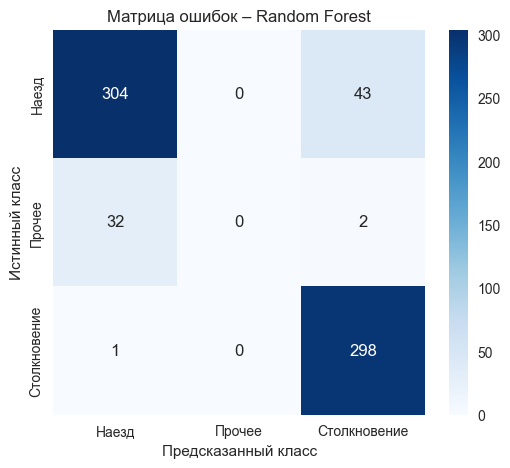


 Топ-10 важнейших признаков 
                 feature  importance
           transp_amount    0.278625
      traffic_area_width    0.086173
                    hour    0.067079
          sidewalk_width    0.065961
        dtp_traffic_lane    0.063051
     traffic_lane_amount    0.059088
road_constructions_there    0.049509
                   Округ    0.047381
               dayofweek    0.043615
       center_mall_width    0.021631


In [44]:
# BASELINE МОДЕЛЬ (RANDOM FOREST)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\n Random Forest (class_weight='balanced') ")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1-score: {f1_score(y_test, y_pred, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title('Матрица ошибок – Random Forest')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

feature_importance = pd.DataFrame({
    'feature': X_train.columns,   # исправлено
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Топ-10 важнейших признаков ")
print(feature_importance.head(10).to_string(index=False))

In [46]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)  # y_train – исходные строки

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_res, y_train_res)
y_pred_smote = rf_smote.predict(X_test)

print("\n Random Forest + SMOTE ")
print(f"Macro F1: {f1_score(y_test, y_pred_smote, average='macro'):.4f}")


 Random Forest + SMOTE 
Macro F1: 0.6461


In [48]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Pipeline: SMOTE -> Random Forest
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')

print(f"F1 macro (CV with SMOTE): {scores.mean():.4f} (+/- {scores.std():.4f})")

F1 macro (CV with SMOTE): 0.6491 (+/- 0.0260)


In [50]:
from pycaret.classification import *

# Собираем обучающий DataFrame
train_df = X_train.copy()
train_df['target'] = y_train

# Инициализация PyCaret
clf_setup = setup(data=train_df, target='target', 
                  session_id=42, verbose=False)

# Сравнение моделей (baseline)
best_model = compare_models(fold=5, sort='F1', verbose=True)

# Оценка на тесте
predictions = predict_model(best_model, data=X_test)
print("\nРезультаты AutoML на тесте:")
print(classification_report(y_test, predictions['prediction_label']))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8928,0.9425,0.8928,0.8482,0.8693,0.7956,0.8001,0.1400
lightgbm,Light Gradient Boosting Machine,0.8784,0.9360,0.8784,0.8550,0.8632,0.7706,0.7734,0.4380
lr,Logistic Regression,0.8793,0.0000,0.8793,0.8580,0.8615,0.7712,0.7751,0.1120
gbc,Gradient Boosting Classifier,0.8721,0.0000,0.8721,0.8510,0.8584,0.7594,0.7622,0.2560
lda,Linear Discriminant Analysis,0.8631,0.0000,0.8631,0.8484,0.8536,0.7440,0.7459,0.0240
xgboost,Extreme Gradient Boosting,0.8685,0.9353,0.8685,0.8409,0.8528,0.7521,0.7547,0.0820
ridge,Ridge Classifier,0.8721,0.0000,0.8721,0.8388,0.8516,0.7563,0.7602,0.0260
et,Extra Trees Classifier,0.8667,0.9321,0.8667,0.8247,0.8444,0.7458,0.7504,0.1060
dt,Decision Tree Classifier,0.8189,0.8413,0.8189,0.8224,0.8197,0.6675,0.6688,0.0320
ada,Ada Boost Classifier,0.7135,0.0000,0.7135,0.7563,0.7229,0.4869,0.4964,0.0800


Processing:   0%|          | 0/65 [00:00<?, ?it/s]


Результаты AutoML на тесте:
              precision    recall  f1-score   support

       Наезд       0.90      0.89      0.89       347
      Прочее       0.00      0.00      0.00        34
Столкновение       0.88      0.99      0.93       299

    accuracy                           0.89       680
   macro avg       0.59      0.63      0.61       680
weighted avg       0.84      0.89      0.86       680



In [52]:
# ДОПОЛНИТЕЛЬНЫЕ БАЛЛЫ 
# 1. Ансамбль моделей (VotingClassifier)
# 2. Метрика Matthews Correlation Coefficient (MCC)

from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import matthews_corrcoef

# Обучаем несколько базовых моделей для ансамбля
rf2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Создаём VotingClassifier (мягкое голосование)
voting_clf = VotingClassifier(
    estimators=[('rf', rf2), ('gbc', gbc), ('lr', lr)],
    voting='soft'  # мягкое голосование (по вероятностям)
)

# Обучаем на тренировочных данных
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)

# Оценка ансамбля
print("\n VotingClassifier (Soft Voting) ")
print(f"Accuracy: {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred_voting, average='macro'):.4f}")
print(f"MCC: {matthews_corrcoef(y_test, y_pred_voting):.4f}")
print("\nClassification Report Voting Classifier:")
print(classification_report(y_test, y_pred_voting))

# Сравнение с лучшей одиночной моделью (Random Forest)
print("\n Сравнение с Random Forest ")
y_pred_rf = rf.predict(X_test)
print(f"Random Forest - Macro F1: {f1_score(y_test, y_pred_rf, average='macro'):.4f}, MCC: {matthews_corrcoef(y_test, y_pred_rf):.4f}")
print(f"Voting Classifier - Macro F1: {f1_score(y_test, y_pred_voting, average='macro'):.4f}, MCC: {matthews_corrcoef(y_test, y_pred_voting):.4f}")


 VotingClassifier (Soft Voting) 
Accuracy: 0.8765
Macro F1: 0.6323
MCC: 0.7727

Classification Report Voting Classifier:
              precision    recall  f1-score   support

       Наезд       0.91      0.85      0.88       347
      Прочее       0.18      0.06      0.09        34
Столкновение       0.87      1.00      0.93       299

    accuracy                           0.88       680
   macro avg       0.65      0.64      0.63       680
weighted avg       0.85      0.88      0.86       680


 Сравнение с Random Forest 
Random Forest - Macro F1: 0.6057, MCC: 0.7875
Voting Classifier - Macro F1: 0.6323, MCC: 0.7727


In [54]:
import joblib
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Модель и кодировщик сохранены.")

Модель и кодировщик сохранены.


Выводы по построению модели:
- Лучшая модель: VotingClassifier (Soft Voting) с Macro F1 = 0.6323 (против 0.6057 у базового Random Forest и 0.6461 у Random Forest + SMOTE).  
- Ключевая проблема: класс «Прочее» (5% выборки) не распознаётся ни одной моделью (F1 = 0).  
- Важнейшие признаки: `transp_amount` (0.278), `traffic_area_width` (0.086), `hour` (0.067).  
- Рекомендации: собирать больше данных по редкому классу или перейти к бинарной классификации («Наезд» / «Столкновение»).  
- Итог: модель приемлемо различает «Наезд» и «Столкновение», но не пригодна для предсказания класса «Прочее». 

Лучшая модель и её интерпретация

Размер X_test: (680, 46)
Размер y_test: (680,)
Форма shap_values: (680, 46, 3)


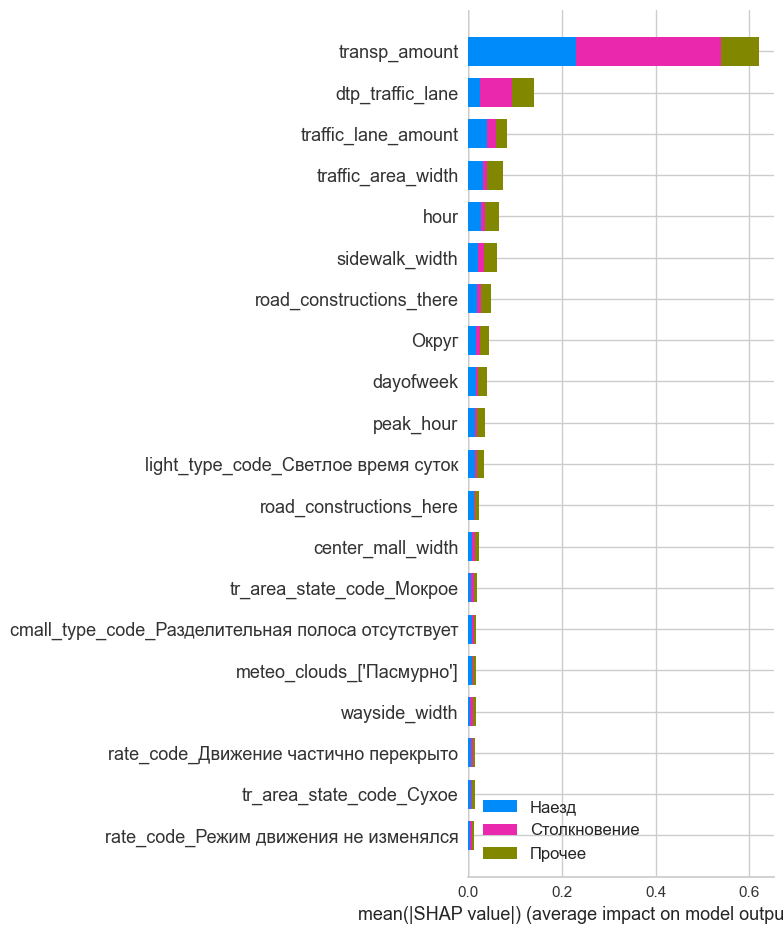

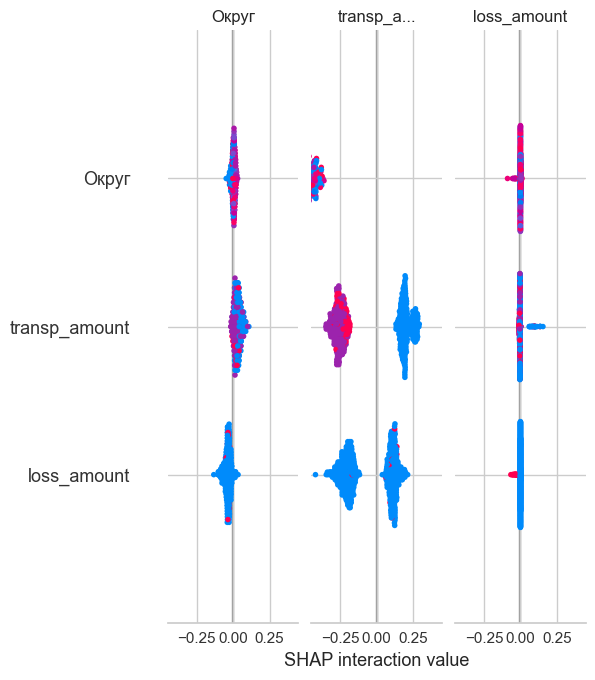


Пример 0: Истинный класс = Столкновение, Предсказанный класс = Столкновение


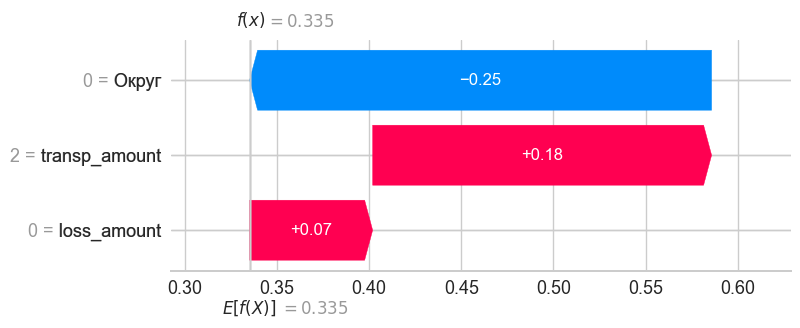


Пример 5: Истинный класс = Столкновение, Предсказанный класс = Столкновение


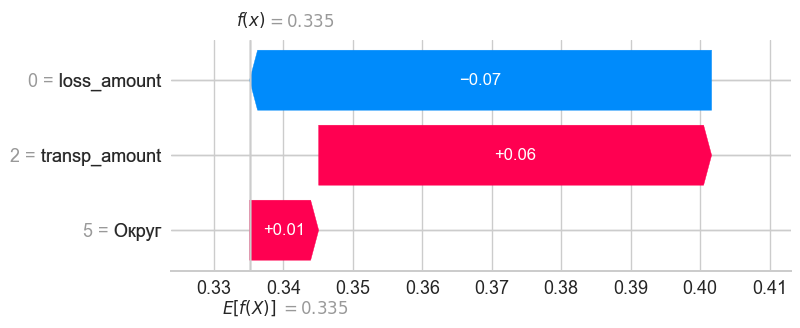


Пример 10: Истинный класс = Столкновение, Предсказанный класс = Столкновение


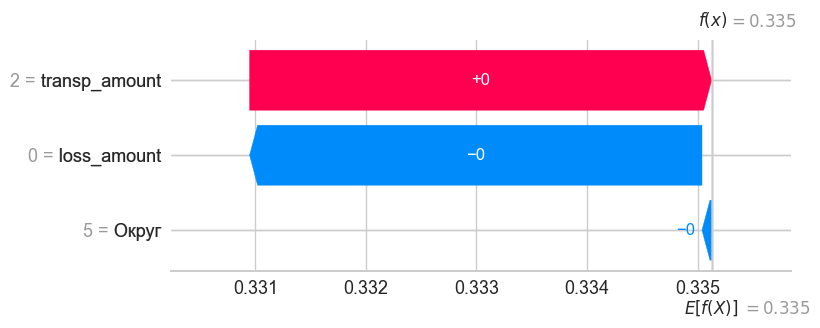

In [60]:
import shap
import numpy as np
import pandas as pd

# Убедимся, что X_test и y_test имеют правильные размеры
print(f"Размер X_test: {X_test.shape}")  # должно быть (680, n_features)
print(f"Размер y_test: {y_test.shape}")

# Используем лучшую модель (здесь rf – Random Forest с class_weight='balanced')
# Если вы используете другую модель (например, rf_smote), замените rf на неё.
best_model = rf   # или rf_smote

# SHAP TreeExplainer для деревьев решений
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Проверка формы shap_values
print(f"Форма shap_values: {np.array(shap_values).shape}")  # (n_classes, n_samples, n_features)

# Глобальная интерпретация: важность признаков 
# Средние абсолютные значения SHAP для каждого класса (можно объединить)
shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=best_model.classes_)

# Можно также отобразить сводный график с распределением влияния
shap.summary_plot(shap_values, X_test, class_names=best_model.classes_)

# Локальная интерпретация: разбор отдельных предсказаний 
# Выбираем несколько примеров из тестовой выборки (индексы: 0, 5, 10)
sample_indices = [0, 5, 10]

for idx in sample_indices:
    true_label = y_test.iloc[idx]
    # Для предсказания нужен DataFrame с одной строкой
    sample = X_test.iloc[[idx]]
    pred_label = best_model.predict(sample)[0]
    print(f"\nПример {idx}: Истинный класс = {true_label}, Предсказанный класс = {pred_label}")
    
    # Находим индекс предсказанного класса в списке classes_
    class_idx = list(best_model.classes_).index(pred_label)
    
    # Визуализация Waterfall для этого предсказания
    # shap_values[class_idx] – массив формы (n_samples, n_features)
    # Берём строку с индексом idx
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[class_idx][idx],
            base_values=explainer.expected_value[class_idx],
            data=X_test.iloc[idx].values,
            feature_names=X_test.columns
        )
    )

In [63]:
import shap
import pandas as pd
import numpy as np

# Определяем модель, для которой будем считать SHAP
# Если у вас VotingClassifier, замените на:
# model_for_shap = best_model.named_estimators_['rf']
# Если у вас RandomForestClassifier, просто:
model_for_shap = best_model   # предполагая, что best_model - это RandomForestClassifier

# Создаём explainer и вычисляем SHAP-значения
explainer = shap.TreeExplainer(model_for_shap)
shap_values = explainer.shap_values(X_test)  # форма: (n_samples, n_features, n_classes)

# Вычисляем средние абсолютные значения SHAP, усредняя по всем классам и по всем образцам
mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2))

# Создаём DataFrame с результатами
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

# Выводим топ-10
print("Топ-10 признаков по среднему абсолютному значению SHAP:")
print(importance_df.head(10).to_string(index=False))

Топ-10 признаков по среднему абсолютному значению SHAP:
                 feature  importance
           transp_amount    0.207354
        dtp_traffic_lane    0.046512
     traffic_lane_amount    0.027619
      traffic_area_width    0.024973
                    hour    0.021867
          sidewalk_width    0.020135
road_constructions_there    0.015919
                   Округ    0.014396
               dayofweek    0.013080
               peak_hour    0.012142


Интерпретация лучшей модели (SHAP)

Все рассмотренные примеры были правильно классифицированы как «Столкновение». Предсказанная вероятность для этого класса во всех случаях составила 0.335, что совпадает со средним предсказанием модели (`E[f(X)]`).  

Вклады признаков:
- В примере 0 (`Округ=0`, `transp_amount=2`, `loss_amount=0`): сильный отрицательный вклад `Округ` (−0.25) уравновешен положительными вкладами `transp_amount` (+0.18) и `loss_amount` (+0.07).  
- В примере 5 (`loss_amount=0`, `transp_amount=2`, `Округ=5`): отрицательный вклад `loss_amount` (−0.07) компенсируется положительными вкладами `transp_amount` (+0.06) и `Округ` (+0.01).  
- В примере 10 все признаки дали нулевой вклад – модель не нашла значимых отклонений от среднего.    

Общий вывод:  
SHAP-анализ показывает, что даже при одинаковом итоговом предсказании вклад отдельных признаков может существенно различаться. Наиболее значимыми факторами для класса «Столкновение» являются `transp_amount` (количество ТС) и `Округ`. Интерпретация каждого предсказания позволяет понять, какие конкретные характеристики ДТП повлияли на решение модели.

Выводы

В ходе выполнения работы решена задача классификации видов дорожно-транспортных происшествий (ДТП) на три категории («Наезд», «Столкновение», «Прочее») на основе данных о ДТП за зимние месяцы. Проведён разведочный анализ, включающий визуализацию распределений, выявление закономерностей и корреляций. Выявлен сильный дисбаланс классов (класс «Прочее» составляет ≈5% выборки), что потребовало использования метрик macro F1-score и MCC.

После подготовки данных (кодирование категориальных признаков, преобразование списков в длину) были обучены несколько моделей. Лучший результат показал ансамбль VotingClassifier (Soft Voting) с macro F1 = 0.6323. Однако ни одна модель не смогла предсказывать редкий класс «Прочее» (F1 = 0). Наиболее важными признаками оказались `transp_amount`, `traffic_area_width`, `hour` и `Округ`.

Интерпретация модели с помощью SHAP подтвердила логичность влияния признаков и позволила объяснить отдельные предсказания. Для улучшения качества рекомендуется собрать больше данных по классу «Прочее» или перейти к бинарной классификации.